In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def analyze_multiple_bases(df, bases=["USD", "EUR", "GBP", "JPY", "CNY"], majors=["USD", "EUR", "GBP", "JPY", "CNY"]):
    for base in bases:
        print(f"\n[INFO] Analyzing base currency: {base}")
        filtered_df = df[(df["base_currency"] == base) & (df["target_currency"].isin(majors))]

        if filtered_df.empty:
            print(f"[WARNING] No data found for base currency '{base}'")
            continue

        plt.figure(figsize=(14, 6))
        sns.lineplot(data=filtered_df, x="date", y="exchange_rate", hue="target_currency")
        plt.title(f"Exchange Rate Trends (Base = {base})")
        plt.xlabel("Date")
        plt.ylabel("Exchange Rate")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        filtered_df = filtered_df.sort_values("date")
        volatility_frames = []

        print("[INFO] Data points per target currency:")
        print(filtered_df["target_currency"].value_counts())

        for currency in majors:
            sub_df = filtered_df[filtered_df["target_currency"] == currency].copy()
            sub_df = sub_df.set_index("date").sort_index()

            if len(sub_df) < 5:
                print(f"[SKIPPED] Not enough data for {currency}")
                continue

            sub_df["rolling_std"] = sub_df["exchange_rate"].rolling(window=5).std()
            sub_df["target_currency"] = currency
            volatility_frames.append(sub_df.reset_index())

        if volatility_frames:
            volatility_df = pd.concat(volatility_frames, ignore_index=True)
            volatility_df = volatility_df.dropna(subset=["rolling_std"])

            plt.figure(figsize=(14, 6))
            sns.lineplot(data=volatility_df, x="date", y="rolling_std", hue="target_currency")
            plt.title(f"5-Observation Rolling Volatility (Base = {base})")
            plt.xlabel("Date")
            plt.ylabel("Rolling Std Dev")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        else:
            print("[WARNING] Not enough data to compute rolling volatility.")

    return df



[INFO] Analyzing base currency: USD


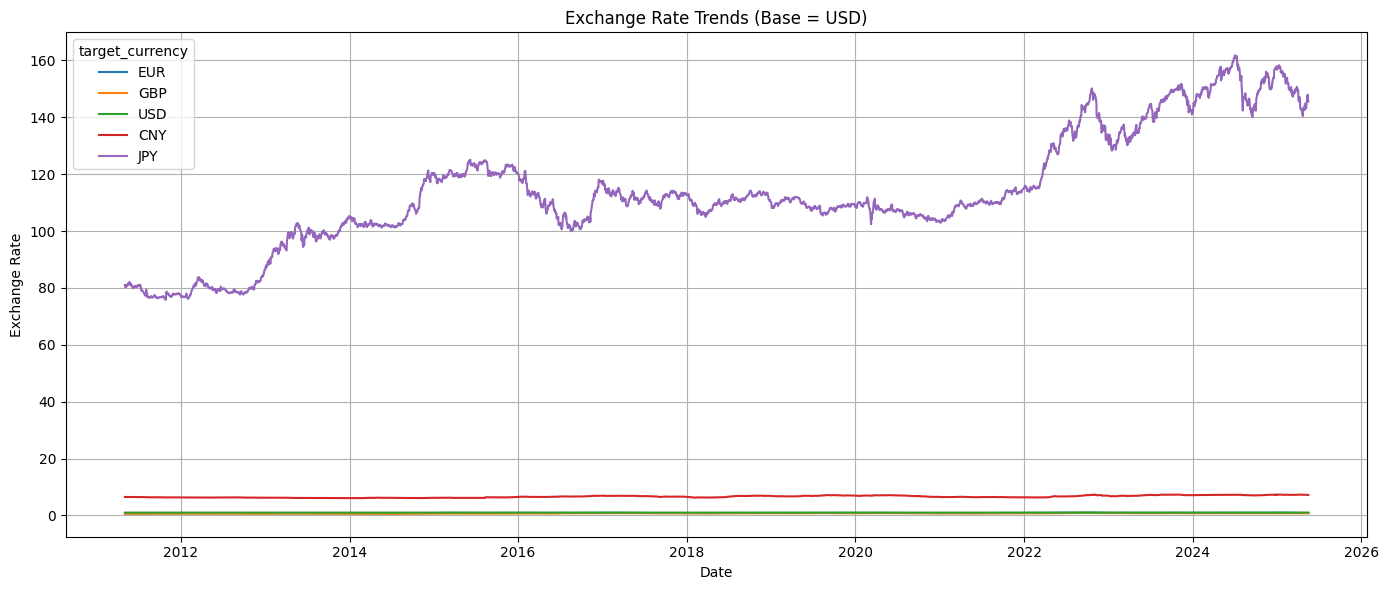

[INFO] Data points per target currency:
target_currency
EUR    5127
GBP    5127
USD    5127
CNY    5127
JPY    5127
Name: count, dtype: int64


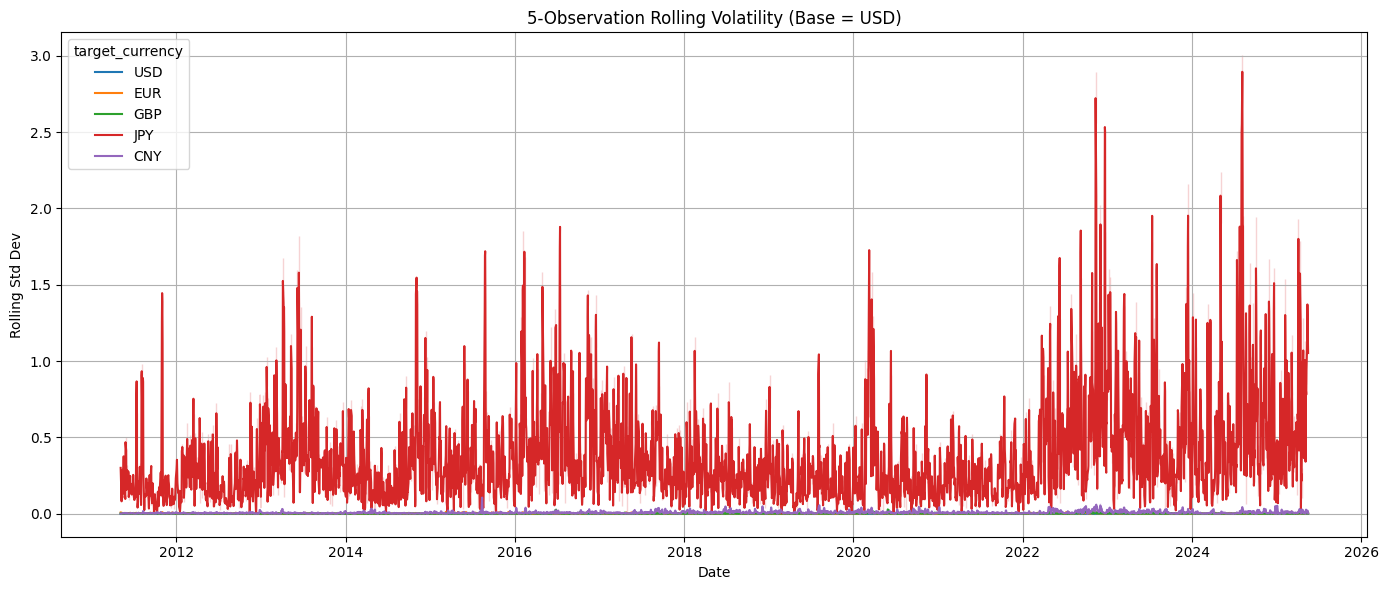


[INFO] Analyzing base currency: EUR


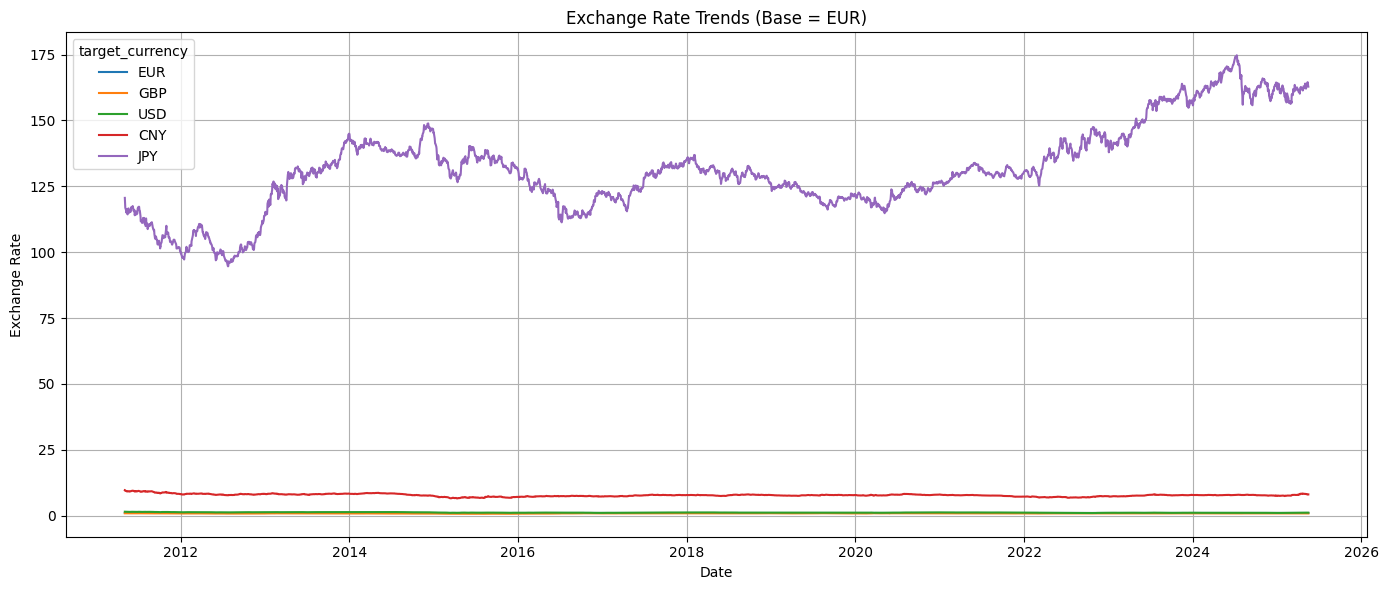

[INFO] Data points per target currency:
target_currency
EUR    5127
GBP    5127
USD    5127
CNY    5127
JPY    5127
Name: count, dtype: int64


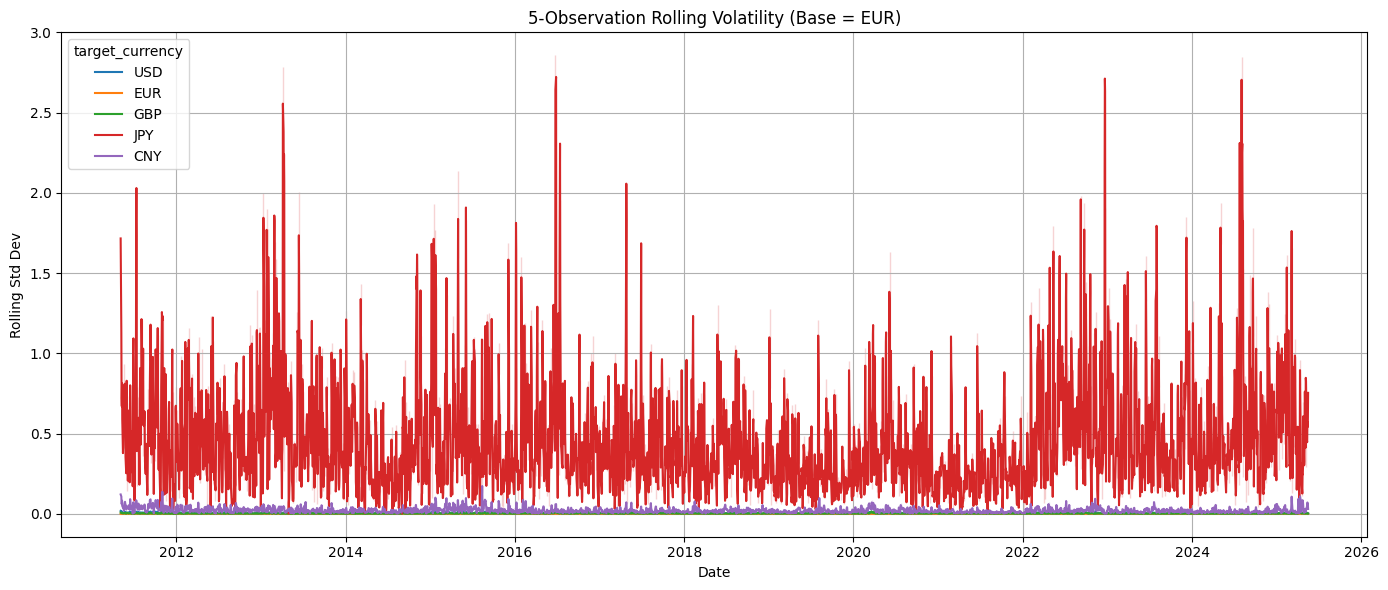


[INFO] Analyzing base currency: GBP


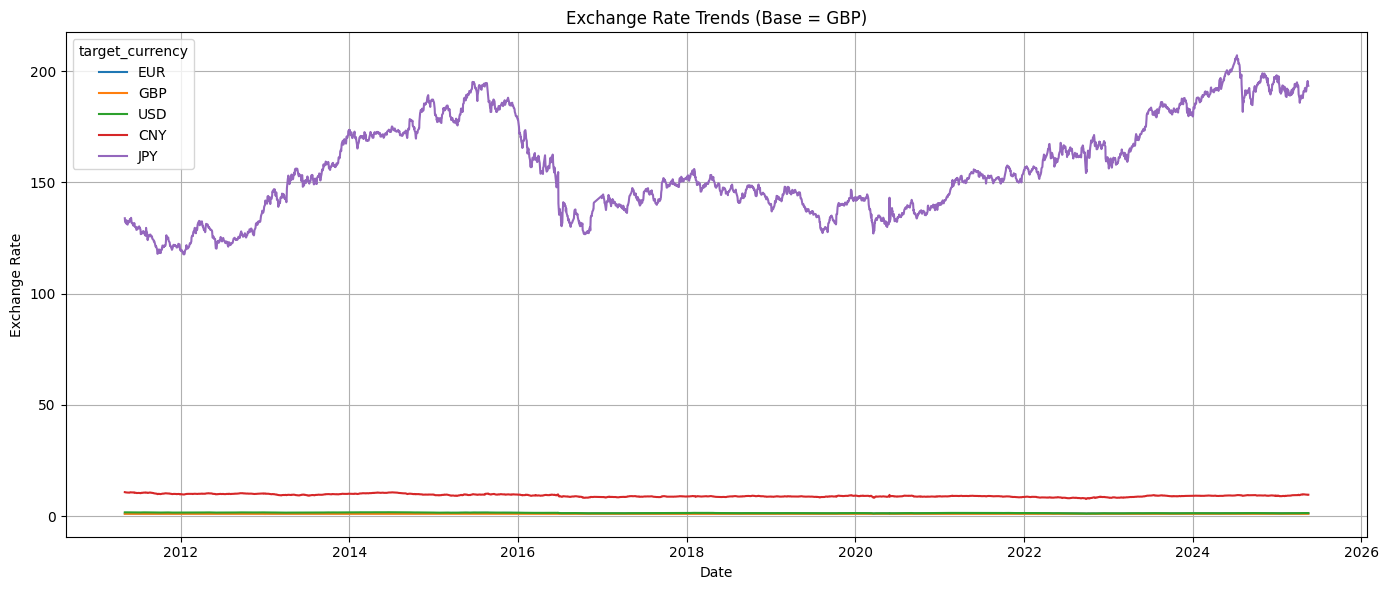

[INFO] Data points per target currency:
target_currency
EUR    5097
GBP    5097
USD    5097
CNY    5097
JPY    5097
Name: count, dtype: int64


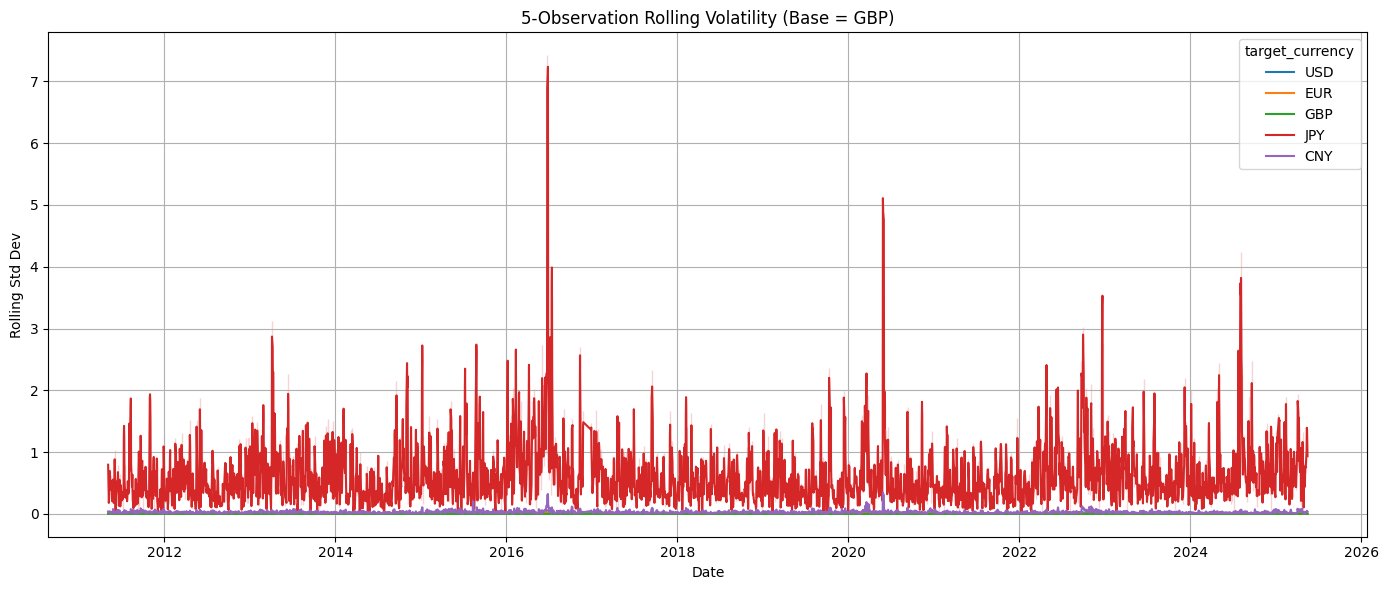


[INFO] Analyzing base currency: JPY


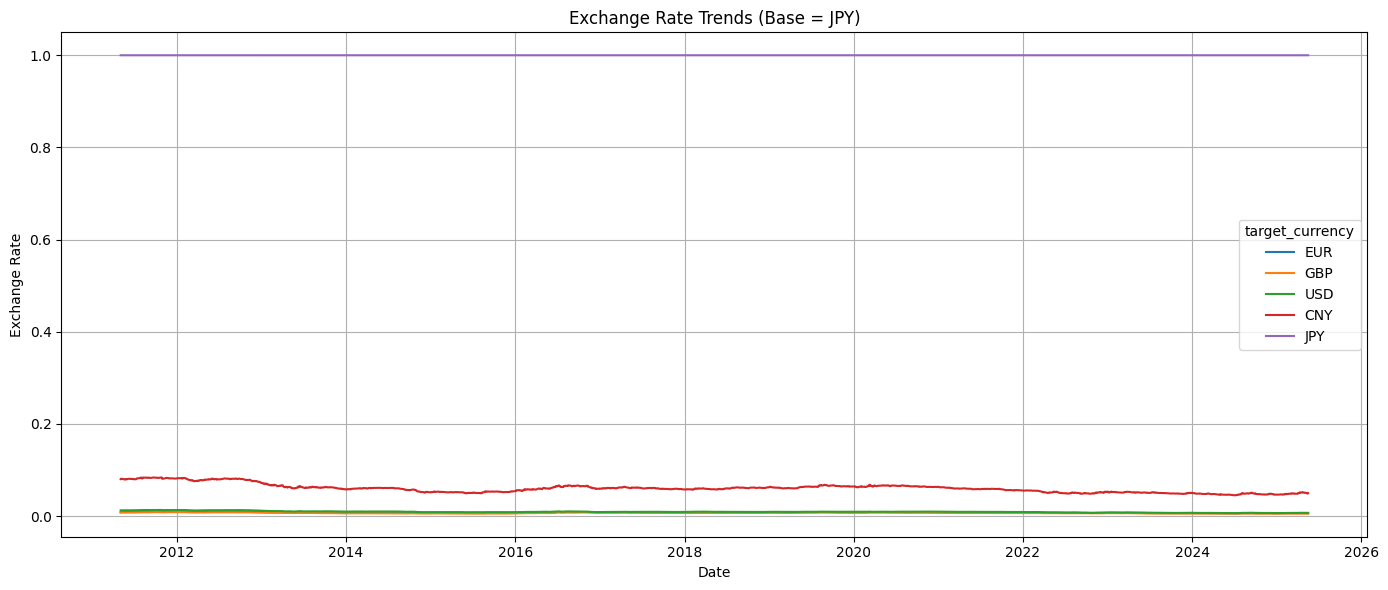

[INFO] Data points per target currency:
target_currency
EUR    5068
GBP    5068
USD    5068
CNY    5068
JPY    5068
Name: count, dtype: int64


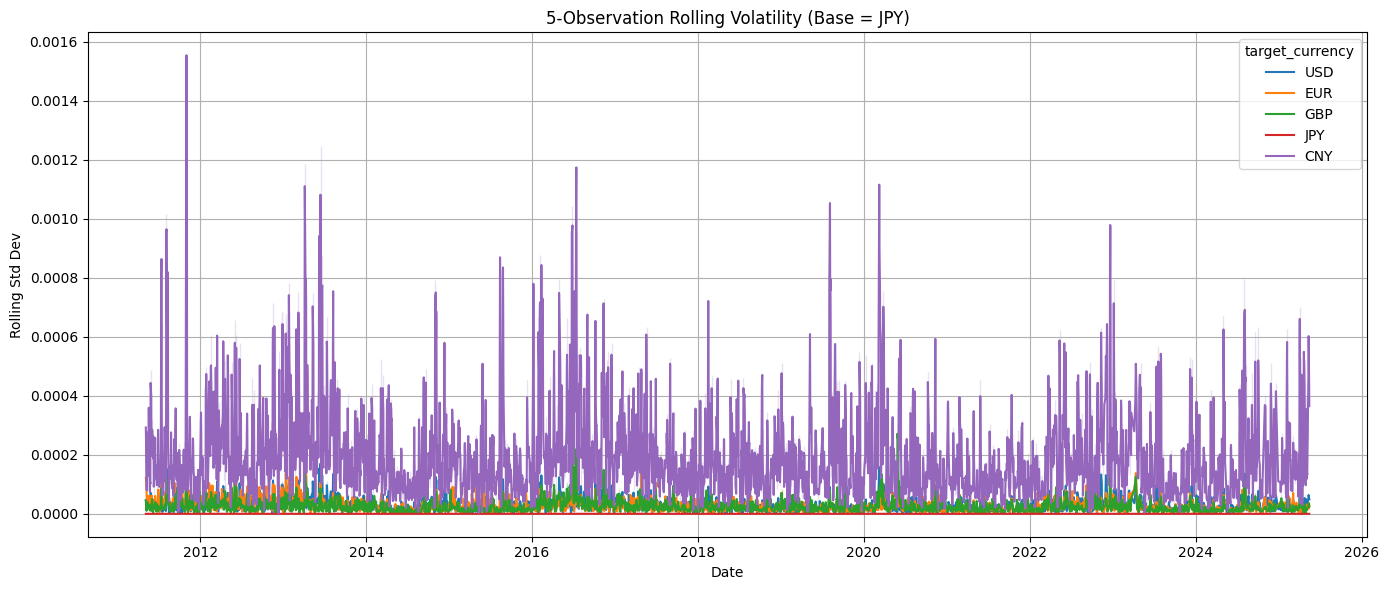


[INFO] Analyzing base currency: CNY


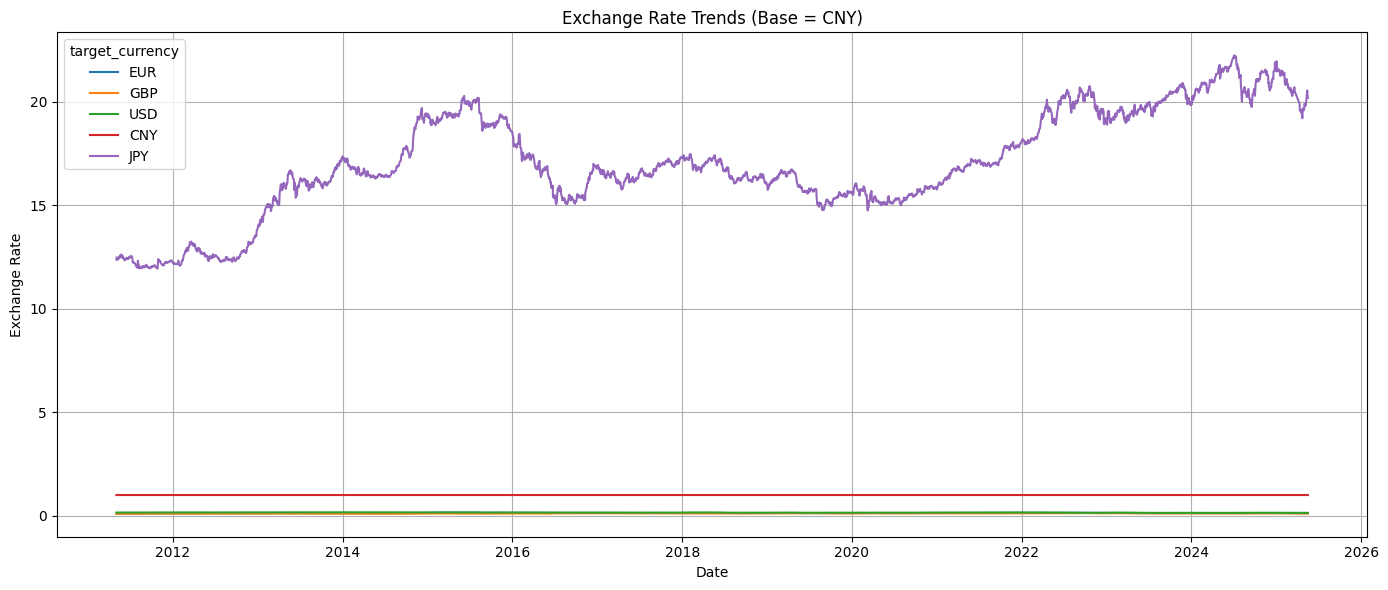

[INFO] Data points per target currency:
target_currency
EUR    5052
GBP    5052
USD    5052
CNY    5052
JPY    5052
Name: count, dtype: int64


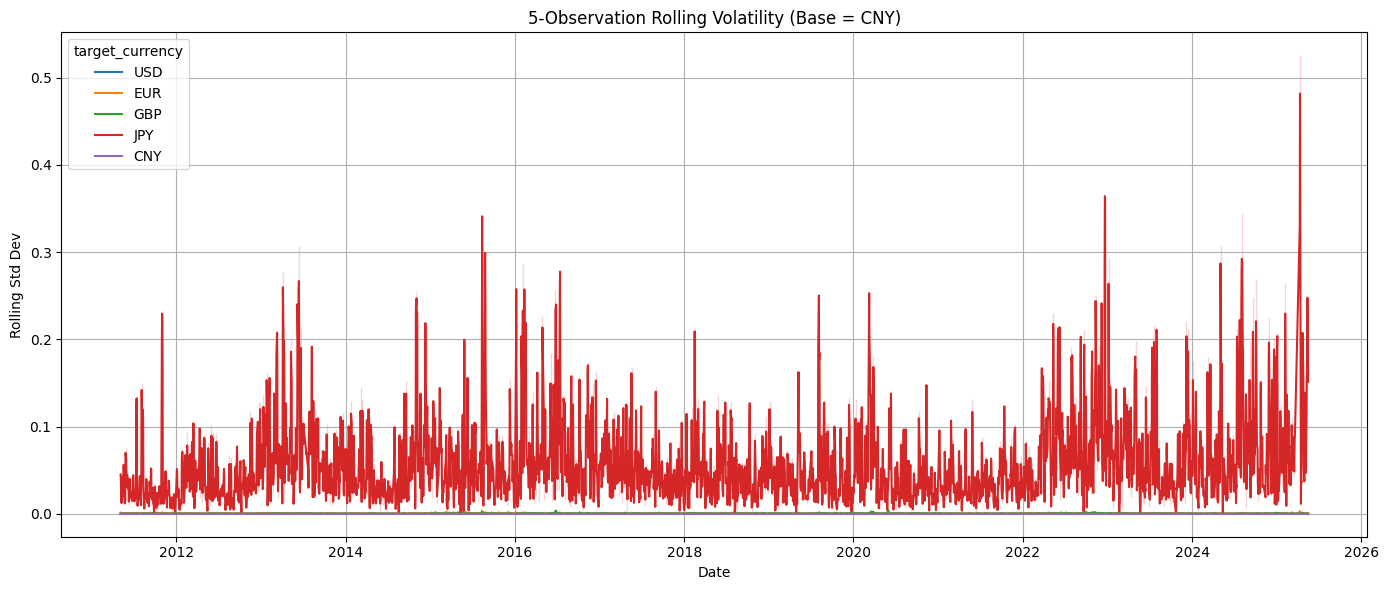

,date,base_currency,target_currency,exchange_rate
0,2011-05-04,CNY,EUR,0.103398
1,2011-05-04,CNY,GBP,0.093143
2,2011-05-04,CNY,USD,0.153877
3,2011-05-04,CNY,DZD,10.970358
4,2011-05-04,CNY,AUD,0.142043
...,...,...,...,...
2928644,2025-05-16,USD,YER,244.166518
2928645,2025-05-16,USD,ZMW,26.762105
2928646,2025-05-16,USD,BYN,3.272567
2928647,2025-05-16,USD,IRR,41972.222222


In [2]:
from downloader import parse_for_EDA

df = parse_for_EDA("data")
analyze_multiple_bases(df, bases=["USD", "EUR", "GBP", "JPY", "CNY"])